In [3]:
import openmm as mm
from openmm import app, unit

import numpy as np
import pandas as pd
import sys

from openmmnapshift.utils import get_napshift_force, get_restricted_bending_force

def genParamsDH(temp,ionic):
    """ Debye-Huckel parameters. """

    kT = 8.3145*temp*1e-3
    # Calculate the prefactor for the Yukawa potential
    fepsw = lambda T : 5321/T+233.76-0.9297*T+0.1417*1e-2*T*T-0.8292*1e-6*T**3
    epsw = fepsw(temp)
    lB = 1.6021766**2/(4*np.pi*8.854188*epsw)*6.02214076*1000/kT
    yukawa_eps = lB*kT
    # Calculate the inverse of the Debye length
    yukawa_kappa = np.sqrt(8*np.pi*lB*ionic*6.02214076/10)
    return yukawa_eps, yukawa_kappa

def get_Ashbaugh_Hatch(lj_eps, cutoff, params, top, lambdas_column):
    energy_expression = 'select(step(r-2^(1/6)*s),4*eps*l*((s/r)^12-(s/r)^6-shift),4*eps*((s/r)^12-(s/r)^6-l*shift)+eps*(1-l))'
    ah = mm.CustomNonbondedForce(energy_expression + '; s=0.5*(s1+s2); l=0.5*(l1+l2); shift=(0.5*(s1+s2)/rc)^12-(0.5*(s1+s2)/rc)^6')
    ah.addGlobalParameter('eps', lj_eps * unit.kilojoules_per_mole)
    ah.addGlobalParameter('rc', float(cutoff) * unit.nanometer)
    ah.addPerParticleParameter('s')
    ah.addPerParticleParameter('l')

    for r in top.residues():
        ah.addParticle([params.loc[r.name].sigmas * unit.nanometer, params.loc[r.name][lambdas_column] * unit.dimensionless])
           
    ah.setNonbondedMethod(mm.CustomNonbondedForce.CutoffPeriodic)
    ah.setCutoffDistance(cutoff*unit.nanometer)
    ah.setForceGroup(0)
    return ah

def get_Yukawa(yukawa_kappa, yukawa_eps, params, top):
    yu = mm.CustomNonbondedForce('q*(exp(-kappa*r)/r-shift); q=q1*q2')
    yu.addGlobalParameter('kappa', yukawa_kappa / unit.nanometer)
    yu.addGlobalParameter('shift', np.exp(-yukawa_kappa * 4.0) / 4.0 / unit.nanometer)
    yu.addPerParticleParameter('q')

    for r in top.residues():
        #sqrt(eps)*sqrt(eps)=eps
        yu.addParticle([params.loc[r.name].q*np.sqrt(yukawa_eps) * unit.nanometer * unit.kilojoules_per_mole])

    yu.setNonbondedMethod(mm.CustomNonbondedForce.CutoffPeriodic)
    yu.setCutoffDistance(4*unit.nanometer)
    yu.setForceGroup(1)
    return yu

def add_bonds(top, bond_length, k_bond):
    harmonic_bond_force = mm.HarmonicBondForce()
    harmonic_bond_force.setUsesPeriodicBoundaryConditions(True)
    exclusions_1_2 = [] # for ah, yu etc.
    for chain in top.chains():
        atoms = [atom for atom in chain.atoms()]
        for i in range(len(chain)-1):
            harmonic_bond_force.addBond(atoms[i].index, atoms[i+1].index, bond_length*unit.nanometer, k_bond*unit.kilojoules_per_mole/(unit.nanometer**2))
            exclusions_1_2.append((atoms[i].index, atoms[i+1].index))
    return harmonic_bond_force, exclusions_1_2


In [4]:
from openmmnapshift.napshiftforce import NapShiftForce
import openmm as mm

x= NapShiftForce()
system = mm.System()
system.addForce(x)

0

## Define simulation parameters

In [5]:
max_K = 25
K_gradient = 0.0001

report_interval = 1000

temperature = 298*unit.kelvin
salt_conc = 0.165
timestep = 10*unit.femtosecond

bond_length = 0.38
k_bond = 8033.0
eps_lj = 0.2 * 4.184 # kcal to kJ/mol
cutoff_lj = 2.2
yukawa_eps, yukawa_kappa = genParamsDH(temperature.value_in_unit(unit.kelvin), salt_conc)
CALVADOS_parameters = pd.read_csv('Data/CALVADOS_parameters.csv', index_col='three')


## Set up CALVADOS2 system

In [6]:
cg_pdb = app.PDBFile('Data/1DJF/CA.pdb')
top = cg_pdb.topology

system = mm.System()
for r in top.residues():
    system.addParticle(CALVADOS_parameters.loc[r.name].MW*unit.amu)
system.setDefaultPeriodicBoxVectors(np.array([10,0,0]), np.array([0,10,0]), np.array([0,0,10]))

ah = get_Ashbaugh_Hatch(eps_lj, cutoff_lj, CALVADOS_parameters, top, 'CALVADOS2')
yu = get_Yukawa(yukawa_eps, yukawa_kappa, CALVADOS_parameters, top)
hb, exclusions_1_2 = add_bonds(top, bond_length, k_bond)
system.addForce(hb)

for i, j in exclusions_1_2:
    ah.addExclusion(i,j)
    yu.addExclusion(i,j)

system.addForce(ah)
system.addForce(yu)

2

## Add Chemical Shift restraints

In [9]:
napshift_force = get_napshift_force(top, 'Data/1DJF/CS.txt', 'Data/1DJF/CS.txt', model_type='CA')
napshift_force.setUsesPeriodicBoundaryConditions(True)
system.addForce(napshift_force)

restricted_angles = get_restricted_bending_force(top)
restricted_angles.setUsesPeriodicBoundaryConditions(True)
system.addForce(restricted_angles)

/home/mina/anaconda3/envs/OpenMMNapShift/lib/python3.11/site-packages/pycamcoil/camcoil_engine.py:108: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  self.df[f_name] = read_csv(f_path, header=None, delim_whitespace=" ",
/home/mina/anaconda3/envs/OpenMMNapShift/lib/python3.11/site-packages/pycamcoil/camcoil_engine.py:108: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  self.df[f_name] = read_csv(f_path, header=None, delim_whitespace=" ",
/home/mina/anaconda3/envs/OpenMMNapShift/lib/python3.11/site-packages/pycamcoil/camcoil_engine.py:108: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  self.df[f_name] = read_csv(f_path, header=None, delim_whitespace=" ",
/home/mina/anaconda3/envs/OpenMMNapShift/lib/pyth

4

## Set up the simulation

In [ ]:
integrator = mm.LangevinMiddleIntegrator(temperature, 0.01/unit.picosecond, timestep)
platform = mm.Platform.getPlatformByName("CUDA")
simulation = app.Simulation(top, system, integrator, platform, {"Precision" : "mixed", 'DeviceIndex' : "0"})
simulation.context.setPositions(cg_pdb.getPositions())
simulation.minimizeEnergy()
simulation.context.setVelocitiesToTemperature(temperature)

## Add reporters

In [ ]:
xtc_reporter = app.XTCReporter('Data/1DJF/output.xtc', report_interval, append=False, enforcePeriodicBox=True)
state_data_reporter = app.StateDataReporter(sys.stdout, report_interval, step=True, time=True, potentialEnergy=True, kineticEnergy=True, totalEnergy=True, temperature=True, volume=True, speed=True)
simulation.reporters.append(xtc_reporter)
simulation.reporters.append(state_data_reporter)

## Simulate!

In [ ]:
print(f"Simulating without CS restraints")
simulation.step(100000)

warmup_steps = int(np.floor(max_K/K_gradient))
print(f"Warming up CS restraints for {len(range(warmup_steps))} steps")
for i in range(warmup_steps):
    simulation.step(1)
    simulation.context.setParameter('NapShift_K', (i*K_gradient))
    simulation.context.setParameter('ReB_K', (i*(1/warmup_steps)))
simulation.context.setParameter('ReB_K', 1)   

print(f"Simulating with CS restraints")
simulation.step(100000)

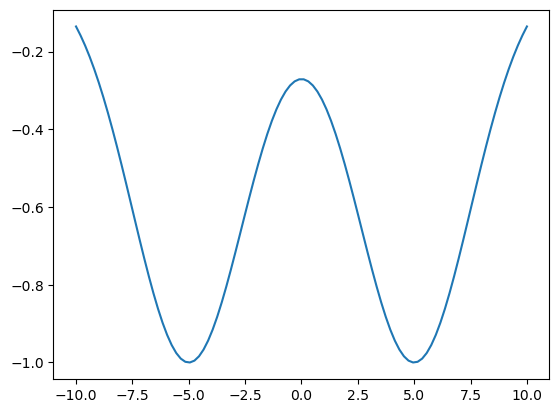

In [21]:
import numpy as np
import matplotlib.pyplot as plt

mu1    = -5
sigma1 = 2.5
mu2    = 5
sigma2 = 2.5

x = np.linspace(-10,10,100)
y = -np.exp(-np.square(x-mu1)/(2*sigma1**2)) - np.exp(-np.square(x-mu2)/(2*sigma2**2))

plt.plot(x,y)

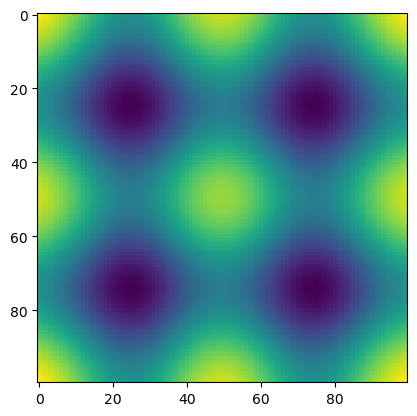

In [22]:
x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

p1 = (-5,-5)
p2 = (5,5)

E = np.zeros((100,100))
for i in range(100):
    for j in range(100):
        r_x_1 = np.abs(x[i]-p1[0])
        r_x_2 = np.abs(x[i]-p2[0])

        r_y_1 = np.abs(y[j]-p1[1])
        r_y_2 = np.abs(y[j]-p1[1])

        Ex = -np.exp(-np.square(x[i]-p2[0])/(2*sigma1**2)) - np.exp(-np.square(x[i]-p1[0])/(2*sigma2**2))
        Ey = -np.exp(-np.square(y[j]-p2[1])/(2*sigma1**2)) - np.exp(-np.square(y[j]-p1[1])/(2*sigma2**2))

        E[i,j] = Ex + Ey

plt.imshow(E)

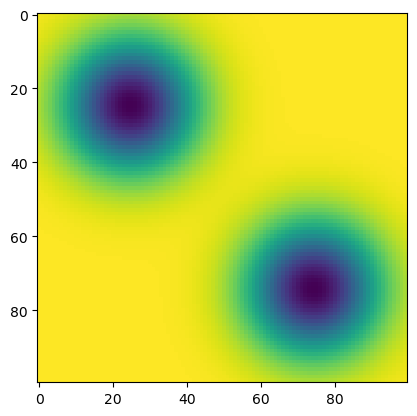

In [23]:
x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

p1 = np.array([-5,-5])
p2 = np.array([5,5])

E = np.zeros((100,100))
for i in range(100):
    for j in range(100):
        r1 = np.linalg.norm(np.array([x[i],y[j]])-p1)
        r2 = np.linalg.norm(np.array([x[i],y[j]])-p2)

        E[i,j] = -np.exp(-np.square(r1)/(2*sigma1**2)) - np.exp(-np.square(r2)/(2*sigma2**2))

plt.imshow(E)